# Load in files and compare

## O2

In [257]:
import bioread as bio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, hilbert
import neurokit2 as nk

ppg_files = [
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\processed_files\sophia_ses-1_ppg.parquet',
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\processed_files\sophia_ses-2_ppg.parquet',
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\processed_files\oren_ses-1_ppg.parquet',
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\processed_files\oren_ses-2_ppg.parquet',
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\processed_files\jack_ses-1_ppg.parquet',
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\processed_files\jack_ses-2_ppg.parquet'
]
acq_files = [
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\29JAN2026 o2 tests acq\Sophia\Sophia_1.acq',
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\29JAN2026 o2 tests acq\Sophia\Sophia_2.acq',
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\29JAN2026 o2 tests acq\Oren\Oren_1.acq',
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\29JAN2026 o2 tests acq\Oren\Oren_2.acq',
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\29JAN2026 o2 tests acq\Jack\Jack_1.acq',
    r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\29JAN2026 o2 tests acq\Jack\Jack_2.acq'
]

o2_times = [[64939, 96694],[69074, 98889], [68753, 88950], [71602, 96275], [65826, 93699], [68398, 98198]]

participant = 2

acq_file = acq_files[participant]
ppg_file = ppg_files[participant]
o2_time_start = o2_times[participant][0]
o2_time_end = o2_times[participant][1]

In [293]:
from scipy.signal import butter, filtfilt, hilbert, envelope, medfilt, find_peaks
from scipy.ndimage import maximum_filter1d, minimum_filter1d
import numpy as np
import neurokit2 as nk

ppg_dc_rs = []
ppg_dc_irs = []
df_ppgs = []
df_o2s = []

for i in range(len(ppg_files)):
    acq_file = acq_files[i]
    ppg_file = ppg_files[i]
    o2_time_start = o2_times[i][0]
    o2_time_end = o2_times[i][1]


    # Read acq file, get data and time start, create df_o2
    data = bio.read_file(acq_file)
    o2_data = data.channels[0]
    o2_time = np.linspace(0,len(o2_data.data) / o2_data.samples_per_second,num=len(o2_data.data),endpoint=False)
    start_marker_index = data.event_markers[1].sample_index

    o2_data_short = o2_data.data[start_marker_index:]
    o2_time_short = np.linspace(0,len(o2_data_short) / o2_data.samples_per_second,num=len(o2_data_short),endpoint=False)

    df_o2 = pd.DataFrame({"time": o2_time_short, "o2": o2_data_short})


    # Read ppg file, create df_ppg, set time as associated with sampling frequency
    ppg_sampling_freq = 200
    df_ppg= pd.read_parquet(ppg_file)
    ppg_time = np.linspace(0,len(df_ppg['ir']) / ppg_sampling_freq,num=len(df_ppg['ir']),endpoint=False)
    df_ppg['time'] = ppg_time

    #RUN DC TRENDING
    #Extract DC trend as 'dc_ratio'
    fs = 200 # sampling rate (Hz) — change if needed
    fc = 0.1 # cutoff frequency (Hz)
    order = 2 # biquad
    b_lp, a_lp = butter(2, fc/(fs/2), btype='lowpass')

    # Apply zero-phase filter
    ppg_dc_r = filtfilt(b_lp, a_lp, df_ppg['r'])
    ppg_dc_ir = filtfilt(b_lp, a_lp, df_ppg['ir'])
    ppg_dc_g = filtfilt(b_lp, a_lp, df_ppg['g'])

    ppg_dc_rs.append(ppg_dc_r)
    ppg_dc_irs.append(ppg_dc_ir)
    
    df_ppg['dc_ratio'] = ppg_dc_ir/ppg_dc_r
    df_ppg['dc_r'] = ppg_dc_r
    df_ppg['dc_ir'] = ppg_dc_ir
    df_ppg['dc_g'] = ppg_dc_g

    # Set index of both dataframes as time, only keep first time if there is duplicate in index
    df_ppg['time'] = pd.to_datetime("2000-01-01") + pd.to_timedelta(df_ppg['time'], unit='s')
    df_o2['time'] = pd.to_datetime("2000-01-01") + pd.to_timedelta(df_o2['time'], unit='s')
    df_ppg.set_index("time", inplace=True)
    df_o2.set_index("time", inplace=True)

    df_ppg = df_ppg[~df_ppg.index.duplicated(keep='first')]
    df_o2 = df_o2[~df_o2.index.duplicated(keep='first')]

    # Resample o2 so it has same samplying frequency as ppg
    df_o2_resampled = df_o2.reindex(df_o2.index.union(df_ppg.index)).interpolate("time").reindex(df_ppg.index)
    df_o2_resampled = df_o2_resampled[:len(df_ppg['ir'])]



    #AC Method

    # Sliding window median
    # kernel_size must be odd
    kernel_size = 15  # e.g., 5 samples per window
    ppg_r_med = medfilt(df_ppg['r'], kernel_size=kernel_size)
    ppg_ir_med = medfilt(df_ppg['ir'], kernel_size=kernel_size)
    ppg_g_med = medfilt(df_ppg['g'], kernel_size=kernel_size)

    fs = 200 # sampling rate (Hz) — change if needed
    fc_high = 0.5 # cutoff frequency (Hz)
    fc_low = 5 #cutoff frequency (Hz)
    order = 2 # biquad

    # Normalize cutoff
    w_high = fc_high / (fs / 2)
    w_low = fc_low / (fs / 2)

    # Design Butterworth high-pass
    b_hp, a_hp = butter(order, w_high, btype='highpass')
    b_lp, a_lp = butter(order, w_low, btype='lowpass')

    # Apply zero-phase filter
    ppg_hp_r = filtfilt(b_hp, a_hp, ppg_r_med)
    ppg_hp_ir = filtfilt(b_hp, a_hp, ppg_ir_med)
    ppg_hp_g = filtfilt(b_hp, a_hp, ppg_g_med)

    ppg_lp_r = filtfilt(b_lp, a_lp, ppg_hp_r)
    ppg_lp_ir = filtfilt(b_lp, a_lp, ppg_hp_ir)
    ppg_lp_g = filtfilt(b_lp, a_lp, ppg_hp_g)

    df_ppg['r_filt']  = ppg_lp_r
    df_ppg['ir_filt'] = ppg_lp_ir
    df_ppg['g_filt'] = ppg_lp_g

    g_peaks, _ = find_peaks(df_ppg['g_filt'], distance=fs*0.4)  # fs=200Hz, min 0.4s between peaks (~150 bpm)
    g_troughs, _ = find_peaks(-df_ppg['g_filt'], distance=fs*0.4)

    #PERCENTILE AND RAW SIGNAL METHOD
    r_acs = np.zeros_like(df_ppg['r_filt'], dtype=float)
    ir_acs = np.zeros_like(df_ppg['ir_filt'], dtype=float)
    g_acs = np.zeros_like(df_ppg['g_filt'], dtype=float)

    window = 20

    # Ensure troughs start before the first peak
    if g_troughs[0] > g_peaks[0]:
        g_troughs = np.insert(g_troughs, 0, 0)

    for i, peak_idx in enumerate(g_peaks):
        preceding_troughs = g_troughs[g_troughs<peak_idx]
        trough_idx = preceding_troughs[-1]
        if trough_idx<window:
            small_trough_idx = trough_idx
        else:
            small_trough_idx = trough_idx-window
        r_ac = np.max(df_ppg['r_filt'][peak_idx-window : peak_idx+window]) -  np.min(df_ppg['r_filt'][small_trough_idx : trough_idx+window])
        ir_ac = np.max(df_ppg['ir_filt'][peak_idx-window : peak_idx+window]) -  np.min(df_ppg['ir_filt'][small_trough_idx : trough_idx+window])
        g_ac = df_ppg['g_filt'][peak_idx] -  df_ppg['g_filt'][trough_idx]
       
        # Find the next trough after this peak
        next_trough_candidates = g_troughs[g_troughs > peak_idx]
        if len(next_trough_candidates) == 0:
            end_idx = len(df_ppg['g_filt'])  # last interval goes to end of signal
        else:
            end_idx = next_trough_candidates[0]
    
        # Fill AC values for this interval
        r_acs[trough_idx:end_idx] = r_ac
        ir_acs[trough_idx:end_idx] = ir_ac
        g_acs[trough_idx:end_idx] = g_ac

    df_ppg['ac_r'] = r_acs
    df_ppg['ac_ir'] = ir_acs
    df_ppg['ac_g'] = g_acs
    df_ppg['ac_ratio'] = r_acs/ir_acs

    df_ppgs.append(df_ppg)
    df_o2s.append(df_o2_resampled)

    

C:\Users\a_hop\AppData\Local\Temp\ipykernel_5544\2523341740.py:129: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  g_ac = df_ppg['g_filt'][peak_idx] -  df_ppg['g_filt'][trough_idx]
C:\Users\a_hop\AppData\Local\Temp\ipykernel_5544\2523341740.py:146: RuntimeWarning: invalid value encountered in divide
  df_ppg['ac_ratio'] = r_acs/ir_acs
C:\Users\a_hop\AppData\Local\Temp\ipykernel_5544\2523341740.py:129: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  g_ac = df_ppg['g_filt'][peak_idx] -  df_ppg['g_filt'][trough_idx]
C:\Users\a_hop\AppData\Local\Temp\ipykernel_5544\2523341740.py:146: RuntimeWarning: invalid value encountere

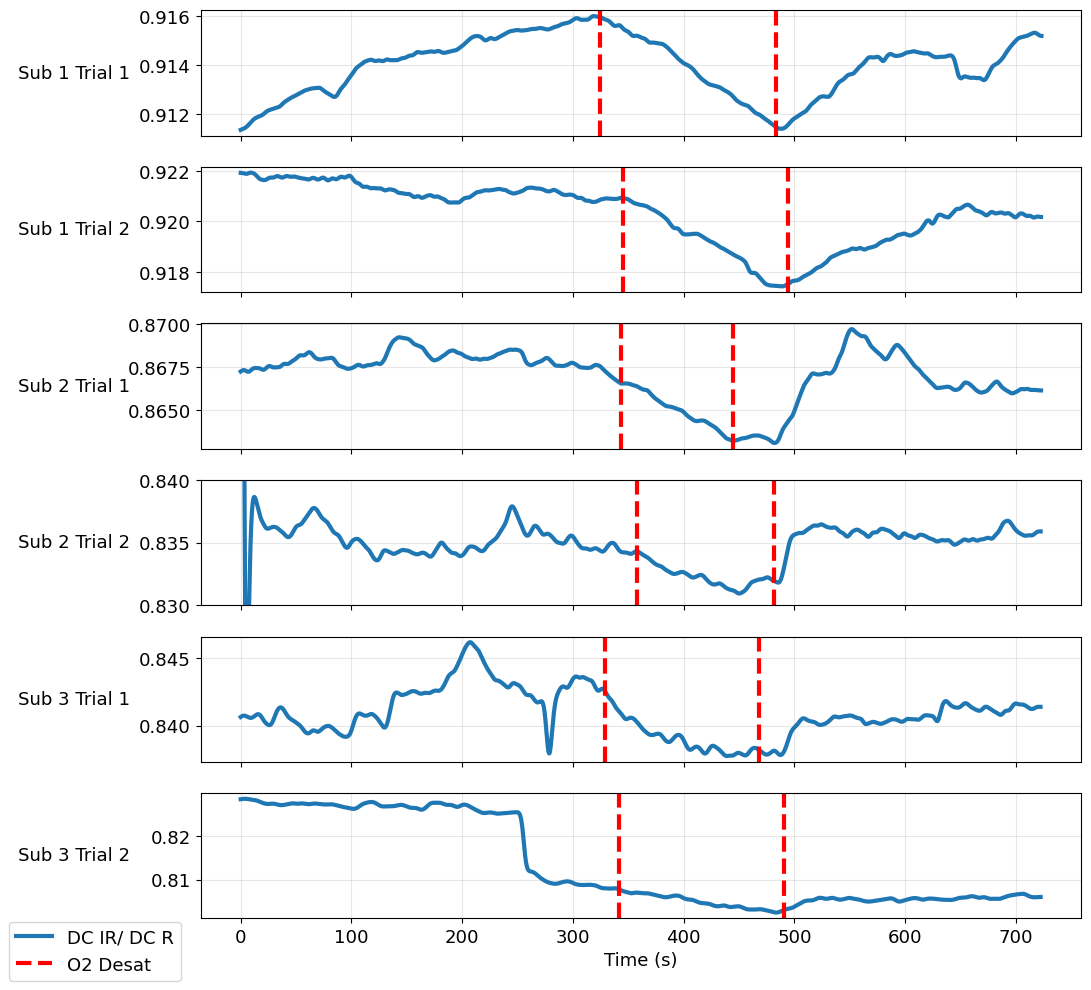

In [285]:
#PLOT RAW DC
fig, axes = plt.subplots(6, 1, figsize=(11, 10), sharex=True)
fs = 200
for i, ax in enumerate(axes):
    t = np.arange(len(ppg_dc_irs[i])) / fs
    ax.plot(t,ppg_dc_irs[i]/ppg_dc_rs[i], label = 'DC IR/ DC R', linewidth=3)# replace with your signals
    trial = 1 if i % 2 == 0 else 2
    subject = i // 2 + 1
    ax.set_ylabel(f"Sub {subject} Trial {trial}", rotation=0, labelpad=40, va='center', ha='right')
    ax.yaxis.set_label_coords(-0.08, 0.5)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=o2_times[i][0]/ fs, color='r', linestyle='--', linewidth=3, label = 'O2 Desat')
    ax.axvline(x=o2_times[i][1]/ fs, color='r', linestyle='--', linewidth=3)
    if i == 3:
        ax.set_ylim(0.83,0.84)
axes[-1].set_xlabel("Time (s)")
# grab legend info from first axis (or any axis)
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc="lower left")
plt.tight_layout()
plt.rcParams.update({
    "font.size": 13
})
plt.savefig(r'C:\Users\a_hop\Downloads\fig.png', dpi=300, bbox_inches="tight")
plt.show()


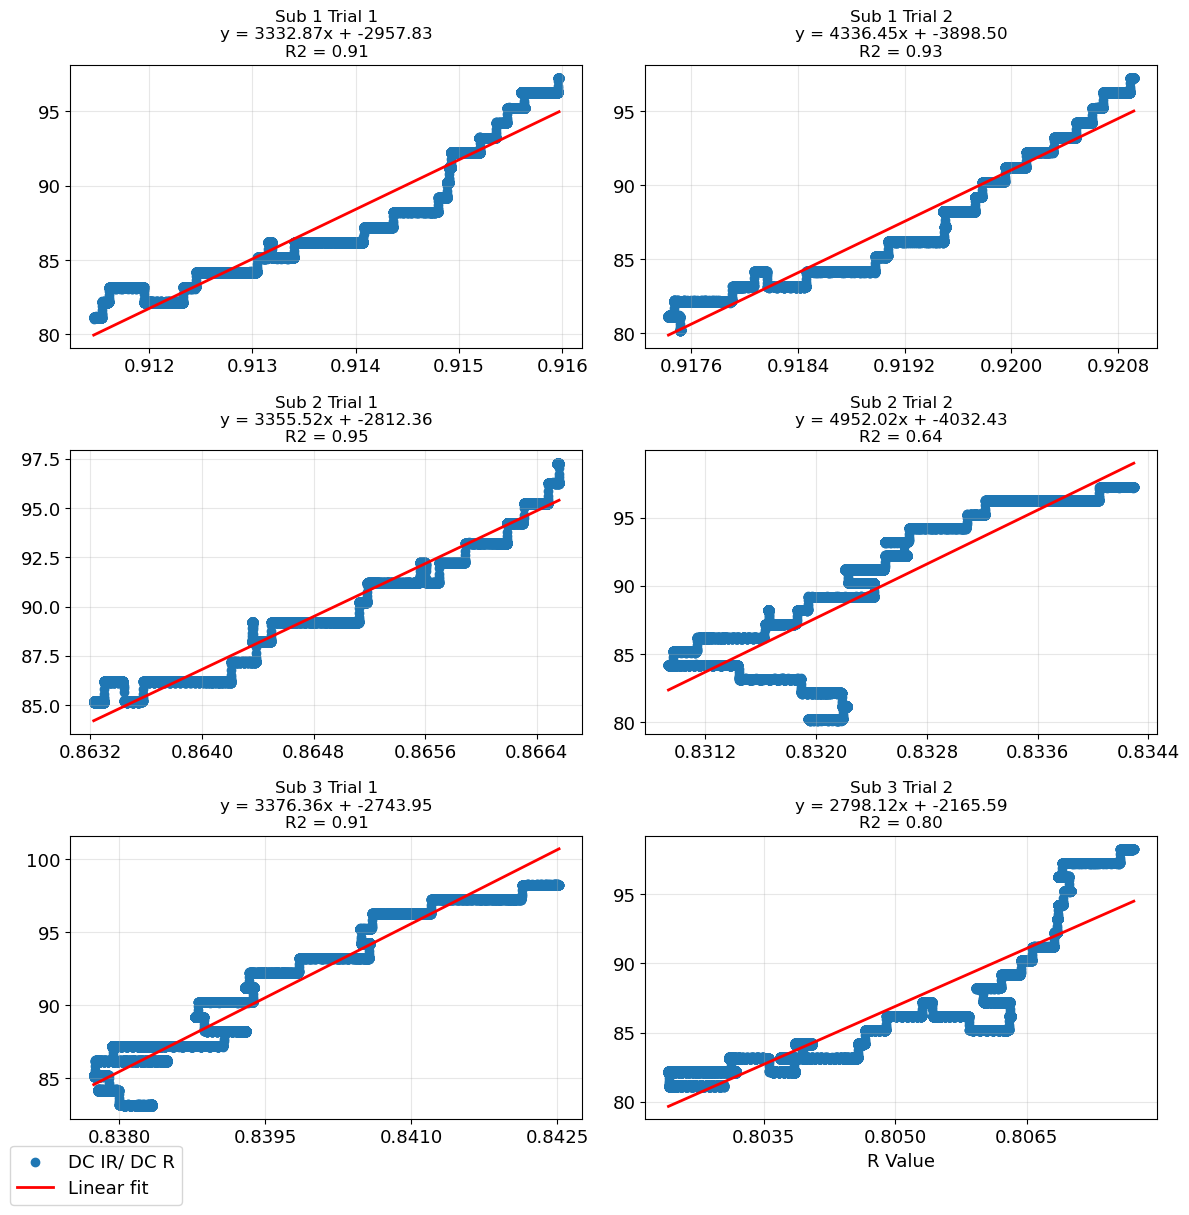

In [286]:
#PLOT DC VS O2 R CALIBRATION CURVE
import matplotlib.ticker as ticker

#PLOT RAW DC RATIO
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.ravel()
for i, ax in enumerate(axes):
    trial = 1 if i % 2 == 0 else 2
    subject = i // 2 + 1
    o2_time_start = o2_times[i][0]
    o2_time_end = o2_times[i][1]
    ax.scatter(df_ppgs[i]['dc_ratio'][o2_time_start:o2_time_end],df_o2s[i]['o2'][o2_time_start:o2_time_end], label = 'DC IR/ DC R', linewidth=1)# replace with your signals
    #ax.set_ylabel(f"Sub {subject} Trial {trial}", rotation=0, labelpad=10, va='center', ha='right')

    slope, intercept = np.polyfit(df_ppgs[i]['dc_ratio'][o2_time_start:o2_time_end], df_o2s[i]['o2'][o2_time_start:o2_time_end], 1)
    x_fit = np.linspace(df_ppgs[i]['dc_ratio'][o2_time_start:o2_time_end].min(), df_ppgs[i]['dc_ratio'][o2_time_start:o2_time_end].max(), len(df_ppgs[i]['dc_ratio'][o2_time_start:o2_time_end]))  # linspace same length as data
    y_fit = slope * x_fit + intercept

    y_fit_actual = slope * df_ppgs[i]['dc_ratio'][o2_time_start:o2_time_end] + intercept
    ax.grid(True, alpha=0.3)
    # Plot regression line
    ax.plot(x_fit, y_fit, color='red', label='Linear fit', linewidth=2)
    y = df_o2s[i]['o2'][o2_time_start:o2_time_end]
    r2 = 1 - np.sum((y - y_fit_actual)**2) / np.sum((y - np.mean(y))**2)

    ax.set_title(
    f"Sub {subject} Trial {trial}\n"
    f"y = {slope:.2f}x + {intercept:.2f}\n"
    f"R2 = {r2:.2f}",
    fontsize=12
    )
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))

axes[-1].set_xlabel("R Value")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc="lower left", bbox_to_anchor=(0, -0.02))
plt.tight_layout()
# plt.rcParams.update({
#     "font.size": 13
# })
plt.savefig(r'C:\Users\a_hop\Downloads\fig2.png', dpi=300, bbox_inches="tight")
plt.show()



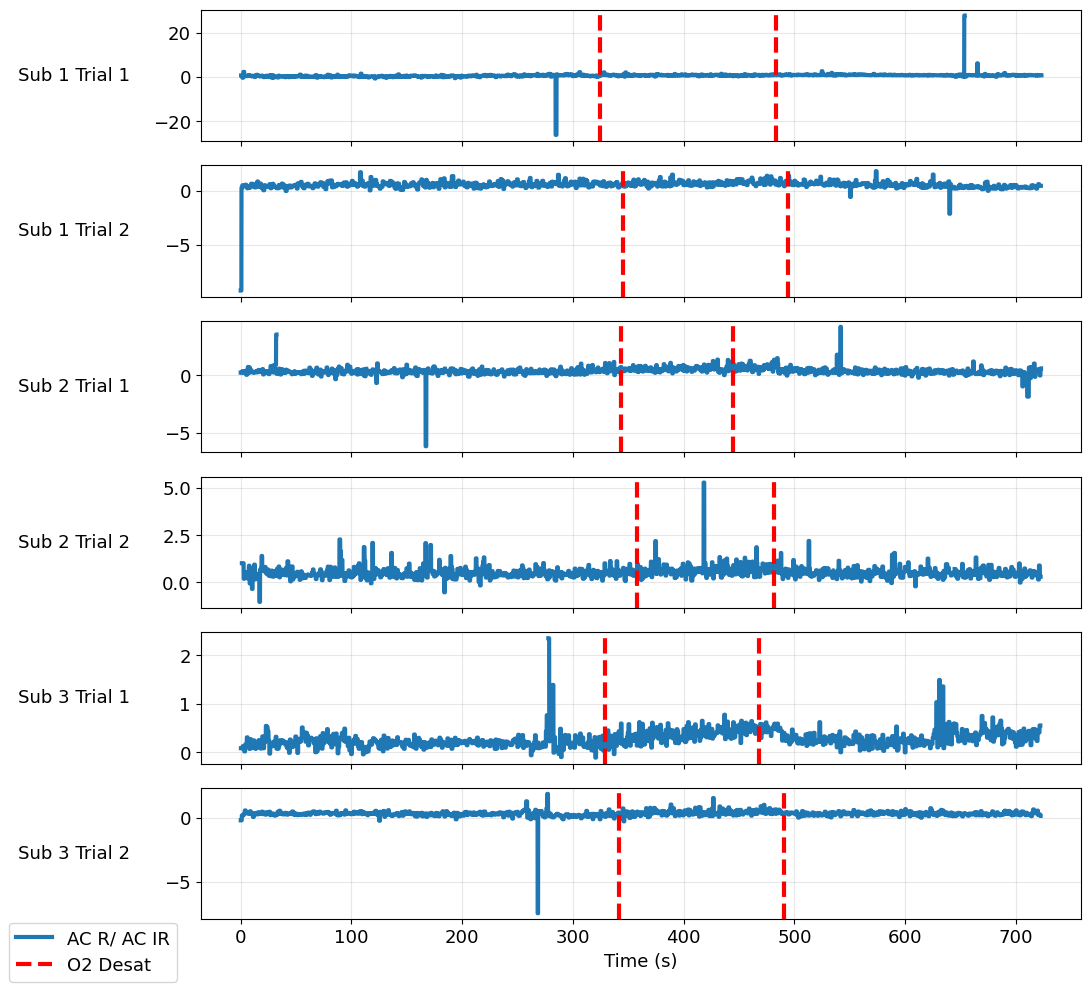

In [287]:
#PLOT RAW AC
fig, axes = plt.subplots(6, 1, figsize=(11, 10), sharex=True)
fs = 200
for i, ax in enumerate(axes):
    t = np.arange(len(df_ppgs[i]['ac_ratio'])) / fs
    ax.plot(t,df_ppgs[i]['ac_ratio'], label = 'AC R/ AC IR', linewidth=3)# replace with your signals
    trial = 1 if i % 2 == 0 else 2
    subject = i // 2 + 1
    ax.set_ylabel(f"Sub {subject} Trial {trial}", rotation=0, labelpad=40, va='center', ha='right')
    ax.yaxis.set_label_coords(-0.08, 0.5)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=o2_times[i][0]/ fs, color='r', linestyle='--', linewidth=3, label = 'O2 Desat')
    ax.axvline(x=o2_times[i][1]/ fs, color='r', linestyle='--', linewidth=3)
    #if i == 3:
    #    ax.set_ylim(0.83,0.84)
axes[-1].set_xlabel("Time (s)")
# grab legend info from first axis (or any axis)
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc="lower left")
plt.tight_layout()
plt.rcParams.update({
    "font.size": 13
})
#plt.savefig(r'C:\Users\a_hop\Downloads\fig.png', dpi=300, bbox_inches="tight")
plt.show()




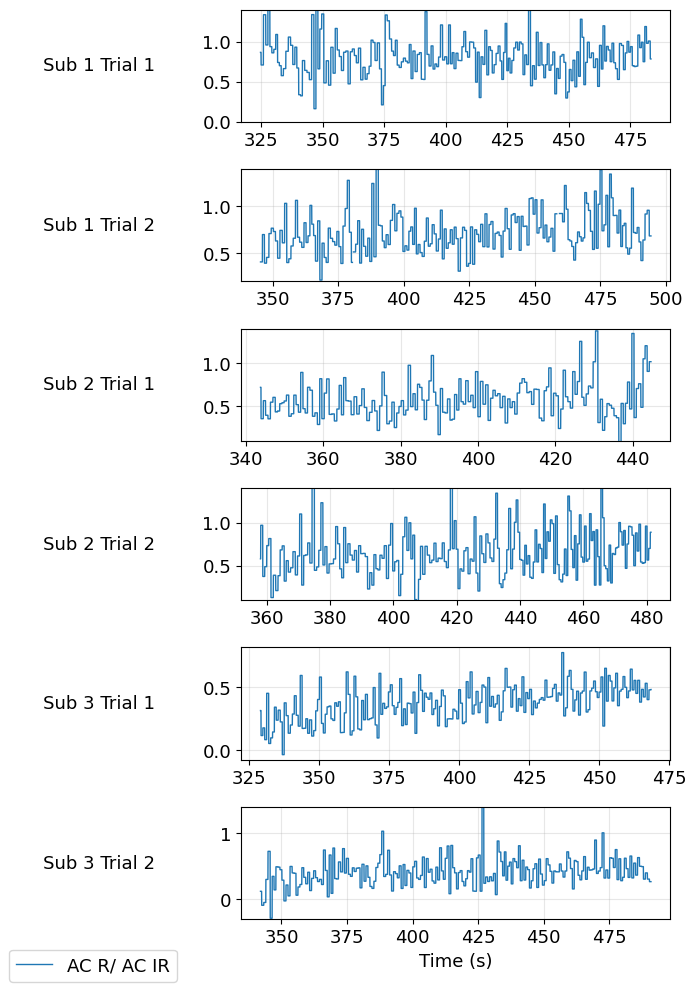

In [289]:
#PLOT RAW AC
fig, axes = plt.subplots(6, 1, figsize=(7, 10))
fs = 200
for i, ax in enumerate(axes):
    o2_time_start = o2_times[i][0]
    o2_time_end = o2_times[i][1]
    t = np.arange(len(df_ppgs[i]['ac_ratio'])) / fs
    
    ac_ratio = df_ppgs[i]['ac_ratio'][o2_time_start:o2_time_end]
    ac_ratio_filtered = medfilt(ac_ratio, kernel_size=7)  # try 3, 5, or 7

    ax.plot(t[o2_time_start:o2_time_end],ac_ratio_filtered, label = 'AC R/ AC IR', linewidth=1)# replace with your signals
    
    trial = 1 if i % 2 == 0 else 2
    subject = i // 2 + 1
    ax.set_ylabel(f"Sub {subject} Trial {trial}", rotation=0, labelpad=40, va='center', ha='right')
    ax.yaxis.set_label_coords(-0.20, 0.5)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_ylim(0,1.4)
    elif i == 1:
        ax.set_ylim(0.2,1.4)
    elif i ==2 or i == 3:
        ax.set_ylim(0.1,1.4)
    elif i==5:
        ax.set_ylim(-0.3,1.4)

axes[-1].set_xlabel("Time (s)")
# grab legend info from first axis (or any axis)
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc="lower left")
plt.tight_layout()
plt.rcParams.update({
    "font.size": 13
})
plt.savefig(r'C:\Users\a_hop\Downloads\fig4.png', dpi=300, bbox_inches="tight")
plt.show()




C:\Users\a_hop\AppData\Local\Temp\ipykernel_5544\4987292.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0].scatter(t2[g_peaks2], g_example[g_peaks2], color = 'blue')
C:\Users\a_hop\AppData\Local\Temp\ipykernel_5544\4987292.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0].scatter(t2[g_troughs2], g_example[g_troughs2], color = 'orange')
C:\Users\a_hop\AppData\Local\Temp\ipykernel_5544\4987292.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value b

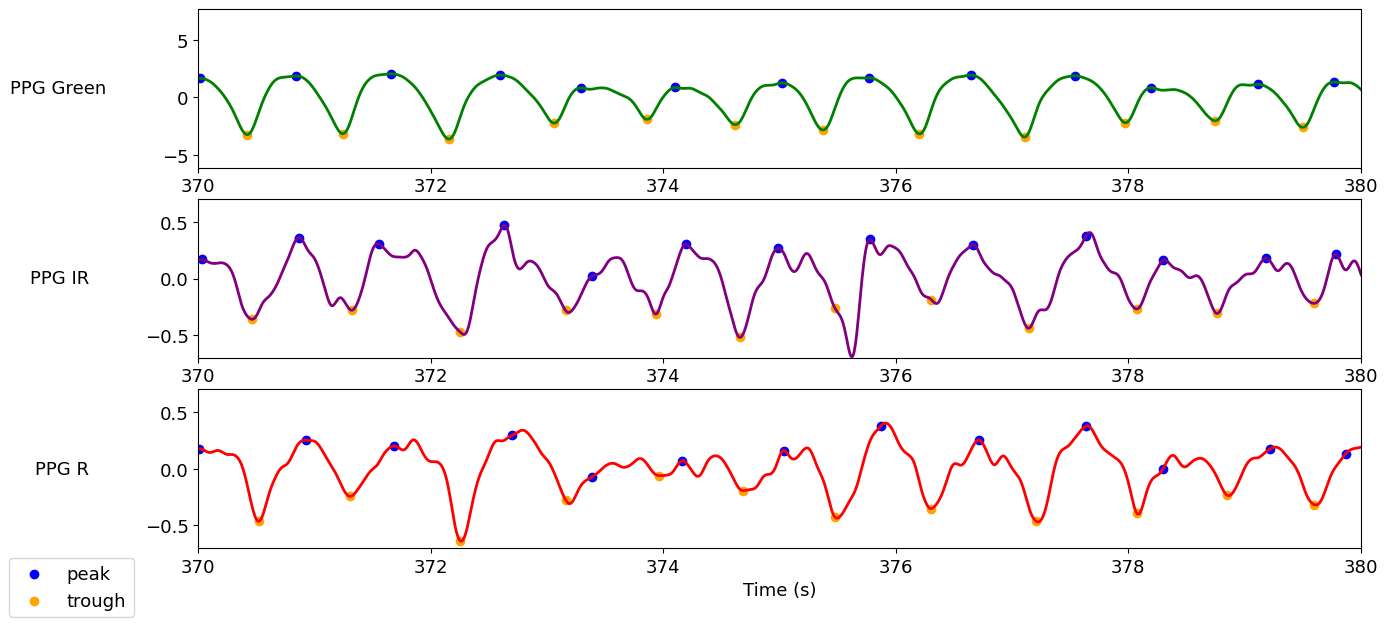

In [291]:
#PLOT RAW AC ALIGNMENT
participant = 0
fig, axes = plt.subplots(3, 1, figsize=(15, 7))
fs = 200
o2_time_start = o2_times[participant][0]
o2_time_end = o2_times[participant][1]
t = np.arange(len(df_ppgs[participant]['g_filt'])) / fs
t2 = t[o2_time_start:o2_time_end]
g_example = df_ppgs[participant]['g_filt'][o2_time_start:o2_time_end]
ir_example = df_ppgs[participant]['ir_filt'][o2_time_start:o2_time_end]
r_example = df_ppgs[participant]['r_filt'][o2_time_start:o2_time_end]
g_peaks2, _ = find_peaks(g_example, distance=fs*0.4)  # fs=200Hz, min 0.4s between peaks (~150 bpm)
g_troughs2, _ = find_peaks(-g_example, distance=fs*0.4)

aligned_peaks_ir = []
aligned_peaks_r = []
aligned_troughs_ir = []
aligned_troughs_r = []
window = 20
for p in g_peaks2:
    start = max(0, p-window)
    end   = min(len(g_example), p+window+1)
    aligned_peaks_ir.append(start + np.argmax(ir_example[start:end]))
    aligned_peaks_r.append(start + np.argmax(r_example[start:end]))
for t in g_troughs2:
    start = max(0, t-window)
    end   = min(len(g_example), t+window + 1)
    aligned_troughs_ir.append(start + np.argmin(ir_example[start:end]))
    aligned_troughs_r.append(start + np.argmin(r_example[start:end]))


start = 370
end = 380
axes[0].plot(t2, g_example, color = 'green', linewidth=2)
axes[0].scatter(t2[g_peaks2], g_example[g_peaks2], color = 'blue')
axes[0].scatter(t2[g_troughs2], g_example[g_troughs2], color = 'orange')
axes[0].set_xlim(start, end)
axes[0].set_ylabel(f"PPG Green", rotation=0, labelpad=40, va='center', ha='right')
#axes[0].yaxis.set_label_coords(-0.20, 0.5)

axes[1].plot(t2, ir_example, color = 'purple', linewidth=2)
axes[1].scatter(t2[aligned_peaks_ir], ir_example[aligned_peaks_ir], color = 'blue')
axes[1].scatter(t2[aligned_troughs_ir], ir_example[aligned_troughs_ir], color = 'orange')
axes[1].set_xlim(start, end)
axes[1].set_ylim(-0.7, 0.7)
axes[1].set_ylabel(f"PPG IR", rotation=0, labelpad=40, va='center', ha='right')
#axes[1].yaxis.set_label_coords(-0.20, 0.5)

axes[2].plot(t2, r_example, color = 'red', linewidth=2)
axes[2].scatter(t2[aligned_peaks_r], r_example[aligned_peaks_r], color = 'blue', label = 'peak')
axes[2].scatter(t2[aligned_troughs_r], r_example[aligned_troughs_r], color = 'orange', label = 'trough')
axes[2].set_xlim(start, end)
axes[2].set_ylim(-0.7, 0.7)
axes[2].set_ylabel(f"PPG R", rotation=0, labelpad=40, va='center', ha='right')
axes[2].set_xlabel("Time (s)")

handles, labels = axes[2].get_legend_handles_labels()

fig.legend(handles, labels, loc="lower left")

plt.savefig(r'C:\Users\a_hop\Downloads\fig5.png', dpi=300, bbox_inches="tight")
plt.show()


In [299]:
#CALCULATE PULSATILE INDEX
perfusion_indices_ir = []
perfusion_indices_r = []
perfusion_indices_g = []
for i in range(len(df_ppgs)):
    perfusion_indices_ir.append(np.mean(df_ppgs[i]['ac_ir']/df_ppgs[i]['dc_ir']))
    perfusion_indices_r.append(np.mean(df_ppgs[i]['ac_r']/df_ppgs[i]['dc_r']))
    perfusion_indices_g.append(np.mean(df_ppgs[i]['ac_g']/df_ppgs[i]['dc_g']))
perfusion_indices_ir = np.array(perfusion_indices_ir)
perfusion_indices_r = np.array(perfusion_indices_r)
perfusion_indices_g = np.array(perfusion_indices_g)


In [300]:
perfusion_indices_ir = perfusion_indices_ir.reshape(-1, 2)
perfusion_indices_ir = perfusion_indices_ir.mean(axis=1) * 100
print(perfusion_indices_ir)

perfusion_indices_r = perfusion_indices_r.reshape(-1, 2)
perfusion_indices_r = perfusion_indices_r.mean(axis=1) * 100
print(perfusion_indices_r)

perfusion_indices_g = perfusion_indices_g.reshape(-1, 2)
perfusion_indices_g = perfusion_indices_g.mean(axis=1) * 100
print(perfusion_indices_g)

[0.01114318 0.01079678 0.02582295]
[0.00686245 0.00428587 0.00765419]
[0.09270949 0.26815665 0.16109755]


# ETC

In [246]:
aligned_peaks_ir = []
aligned_peaks_r = []
aligned_troughs_ir = []
aligned_troughs_r = []
ppg_g_short = ppg_g[o2_time_start:o2_time_end]
ppg_ir_short = ppg_ir[o2_time_start:o2_time_end]
ppg_r_short = ppg_r[o2_time_start:o2_time_end]
peaks, _ = find_peaks(ppg_g_short, distance=fs*0.4)  # fs=200Hz, min 0.4s between peaks (~150 bpm)

# Detect troughs by inverting the signal
troughs, _ = find_peaks(-ppg_g_short, distance=fs*0.4)
window = 20
for p in peaks:
    start = max(0, p-window)
    end   = min(len(ppg_g_short), p+window+1)
    aligned_peaks_ir.append(start + np.argmax(ppg_ir_short[start:end]))
    aligned_peaks_r.append(start + np.argmax(ppg_r_short[start:end]))
for t in troughs:
    start = max(0, t-window)
    end   = min(len(ppg_g_short), t+window + 1)
    aligned_troughs_ir.append(start + np.argmin(ppg_ir_short[start:end]))
    aligned_troughs_r.append(start + np.argmin(ppg_r_short[start:end]))

NameError: name 'ppg_g' is not defined

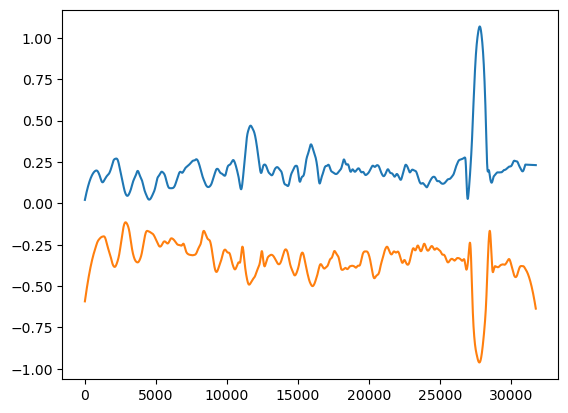

In [178]:
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter
x = np.arange(len(ppg_ir_short))
upper_ir = PchipInterpolator(aligned_peaks_ir, ppg_ir_short[aligned_peaks_ir])(x) 
lower_ir = PchipInterpolator(aligned_troughs_ir, ppg_ir_short[aligned_troughs_ir])(x)
upper_ir = savgol_filter(upper_ir, 1500, 2) 
lower_ir = savgol_filter(lower_ir, 1500, 2)

x = np.arange(len(ppg_r_short))
upper_r = PchipInterpolator(aligned_peaks_r, ppg_r_short[aligned_peaks_r])(x) 
lower_r = PchipInterpolator(aligned_troughs_r, ppg_r_short[aligned_troughs_r])(x)
upper_r = savgol_filter(upper_r, 1500, 2) 
lower_r = savgol_filter(lower_r, 1500, 2)

upper_g = PchipInterpolator(peaks, ppg_g_short[peaks])(x) 
lower_g = PchipInterpolator(troughs, ppg_g_short[troughs])(x)
#upper_g= savgol_filter(upper_g, 1500, 2) 
#lower_g = savgol_filter(lower_g, 1500, 2)
plt.plot(upper_r)
plt.plot(lower_r)

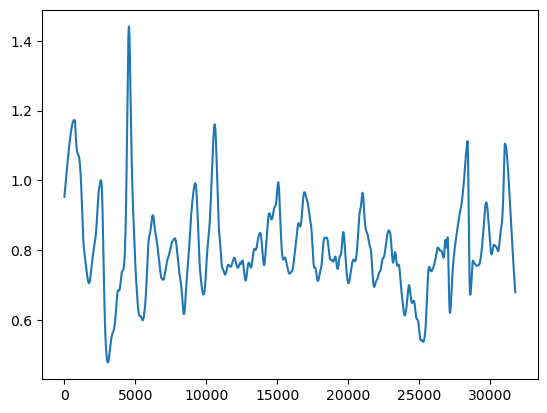

In [179]:
plt.plot((upper_r-lower_r)/(upper_ir-lower_ir))
#plt.ylim(0.2, 1)


In [252]:
#RMS METHOD
import numpy as np

def sliding_rms(signal, window_size, step=1):
    signal = np.asarray(signal)
    rms_values = []

    for start in range(0, len(signal) - window_size + 1, step):
        window = signal[start:start + window_size]
        rms_values.append(np.sqrt(np.mean(window**2)))

    return np.array(rms_values)
ac_ir = sliding_rms(ppg_ir, window_size=200*10)
ac_r = sliding_rms(ppg_r, window_size=200*10)

# ppg_g_short = ppg_g[o2_time_start:o2_time_end]
# ppg_ir_short = ppg_ir[o2_time_start:o2_time_end]
# ppg_r_short = ppg_r[o2_time_start:o2_time_end]

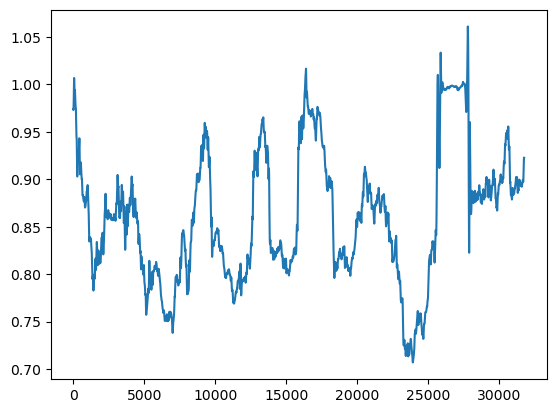

In [253]:
plt.plot((ac_r[o2_time_start:o2_time_end])/(ac_ir[o2_time_start:o2_time_end]))


In [57]:
#PERCENTILE METHOD
signal = ppg_ir[o2_time_start:o2_time_end]

windows = []
for i in range(len(troughs) - 1):
    start = troughs[i]
    end   = troughs[i + 1]
    windows.append((start, end))



ac_values_ir = np.zeros(len(signal))

for start, end in windows:
    segment = signal[start:end]

    # optional but IMPORTANT
    #segment = segment - np.median(segment)

    ac = np.percentile(segment, 95) - np.percentile(segment, 5)

    ac_values_ir[start:end] = ac
    #ac_values_r.append(ac)



In [12]:
#PERCENTILE AND RAW SIGNAL METHOD
signal = ppg_r
ac_signal_r = np.zeros_like(signal, dtype=float)
window = 20
# Ensure troughs start before the first peak
if troughs[0] > peaks[0]:
    troughs = np.insert(troughs, 0, 0)
for i, peak_idx in enumerate(peaks):

    preceding_troughs = troughs[troughs<peak_idx]
    trough_idx = preceding_troughs[-1]
    if trough_idx<window:
        new_trough_idx = trough_idx
    else:
        new_trough_idx = trough_idx-window
    new_peak_val = np.max(signal[peak_idx-window : peak_idx+window])
    new_trough_val = np.min(signal[new_trough_idx : trough_idx+window])
    ac = new_peak_val - new_trough_val
    # Find the next trough after this peak
    next_trough_candidates = troughs[troughs > peak_idx]
    if len(next_trough_candidates) == 0:
        end_idx = len(signal)  # last interval goes to end of signal
    else:
        end_idx = next_trough_candidates[0]
    
    # Fill AC values for this interval
    ac_signal_r[trough_idx:end_idx] = ac

In [6]:
#RAW SIGNAL METHOD

signal = ppg_r[o2_time_start:o2_time_end]
ac_signal_r = np.zeros_like(signal, dtype=float)

# Ensure troughs start before the first peak
if troughs[0] > peaks[0]:
    troughs = np.insert(troughs, 0, 0)
for i, peak_idx in enumerate(peaks):
    #print(i)
    #print(peak_idx)
    preceding_troughs = troughs[troughs<peak_idx]
    trough_idx = preceding_troughs[-1]
    ac = signal[peak_idx] - signal[trough_idx]
    # Find the next trough after this peak
    next_trough_candidates = troughs[troughs > peak_idx]
    if len(next_trough_candidates) == 0:
        end_idx = len(signal)  # last interval goes to end of signal
    else:
        end_idx = next_trough_candidates[0]
    
    # Fill AC values for this interval
    ac_signal_r[trough_idx:end_idx] = ac


In [44]:
print(ac_signal)

[0.25817289 0.25817289 0.25817289 ... 0.37541526 0.37541526 0.37541526]


In [5]:
window = np.hanning(len(ppg_g))
windowed_signal = ppg_g * window

# 3. Calculate FFT
n = len(windowed_signal)
fft_values = np.fft.rfft(windowed_signal) # Real FFT for efficiency
frequencies = np.fft.rfftfreq(n, d=1/fs)

# 4. Get Magnitude (Power)
magnitude = np.abs(fft_values)

In [33]:
print(max(aligned_peaks_r), len(ppg_r_short))
print(max(aligned_troughs_r), len(ppg_r_short))

31592 31755
31702 31755


In [48]:
short_time = ppg_data['datetime'][o2_time_start:o2_time_end].to_numpy()



In [236]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import plotly.io as pio


pio.renderers.default = "browser" # opens in browser


# Example: your PPG signals
# df['datetime'] = your timestamps
# ppg_lp = low-pass filtered PPG
# ppg_signed_sq = signed square of filtered PPG


# -----------------------------
# Create figure with 3 rows, 1 column
# -----------------------------
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
vertical_spacing=0.05,
subplot_titles=("Low-pass Filtered PPG", "Signed Squared PPG"))


# Top: filtered PPG
fig.add_trace(go.Scatter(x=short_time, y=ppg_r_short, name='Filtered PPG', line=dict(color='green')),
row=1, col=1)

# fig.add_trace(go.Scatter(
#     x=short_time[aligned_peaks_r],
#     y=ppg_r_short[aligned_peaks_r],
#     mode='markers',
#     marker=dict(color='blue', size=8, symbol='triangle-up'),
#     name='Peaks'
# ), row=1, col=1)

# fig.add_trace(go.Scatter(
#     x=short_time[aligned_troughs_r],
#     y=ppg_r_short[aligned_troughs_r],
#     mode='markers',
#     marker=dict(color='orange', size=8, symbol='triangle-down'),
#     name='Peaks'
# ), row=1, col=1)

# Bottom: signed squared
fig.add_trace(go.Scatter(x=short_time, y=ppg_g_short, name='Signed Square', line=dict(color='red')),
row=2, col=1)

# fig.add_trace(go.Scatter(
#     x=short_time[peaks],
#     y=ppg_g_short[peaks],
#     mode='markers',
#     marker=dict(color='blue', size=8, symbol='triangle-up'),
#     name='Peaks'
# ), row=2, col=1)


# fig.add_trace(go.Scatter(
#     x=short_time[troughs],
#     y=ppg_g_short[troughs],
#     mode='markers',
#     marker=dict(color='orange', size=8, symbol='triangle-down'),
#     name='Peaks'
# ), row=2, col=1)

# -----------------------------
# Layout settings
# -----------------------------
fig.update_layout(
height=600,
width=1000,
showlegend=False,
title_text="PPG Analysis: Filtered & Signed Squared",
)


# Add x-axis range slider (applies to both subplots)
fig.update_layout(
xaxis_rangeslider_visible=False,
xaxis2_rangeslider_visible=True

)


# Make y-axes zoomable
fig.update_yaxes(fixedrange=False, row=1, col=1)
fig.update_yaxes(fixedrange=False, row=2, col=1)


# Axis labels
fig.update_xaxes(title_text="Time", row=2, col=1) # only bottom x-axis
fig.update_yaxes(title_text="IR", row=1, col=1)
fig.update_yaxes(title_text="R", row=2, col=1)


fig.show()

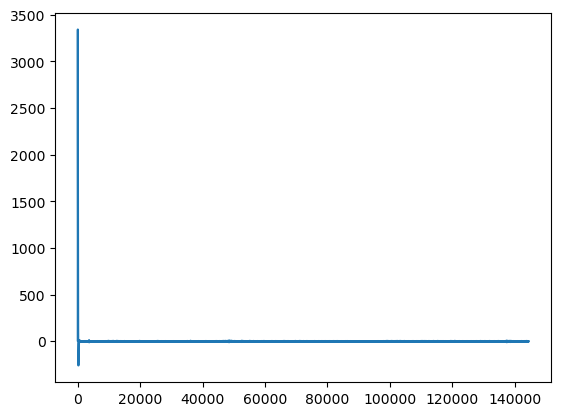

In [96]:
plt.plot(ppg_g)


C:\Users\a_hop\AppData\Local\Temp\ipykernel_10296\3738547318.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(ac_signal_r[60000:100000]/ac_signal_ir[60000:100000])


(-0.5, 1.4)

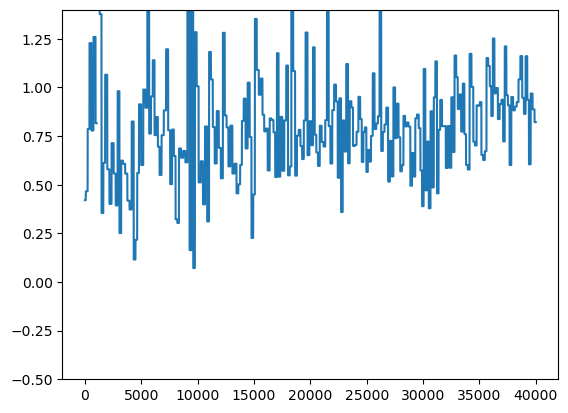

In [20]:
plt.plot(ac_signal_r[60000:100000]/ac_signal_ir[60000:100000])
plt.ylim(-0.5, 1.4)  # set min and max for y-axis


C:\Users\a_hop\AppData\Local\Temp\ipykernel_37924\1710411031.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(ac_signal_r/ac_signal_ir)


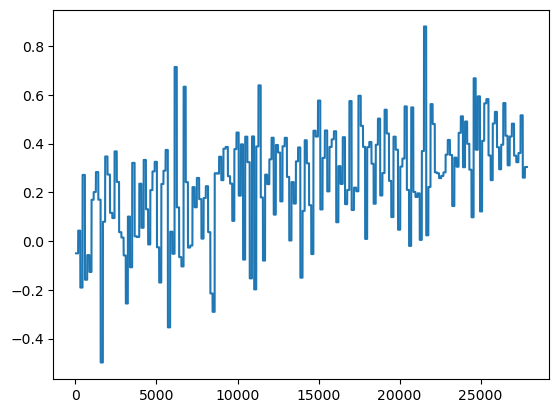

In [12]:
plt.plot(ac_signal_r/ac_signal_ir)


C:\Users\a_hop\AppData\Local\Temp\ipykernel_37924\1928932513.py:4: RuntimeWarning: invalid value encountered in divide
  plt.plot(ac_values_r/ac_values_ir)


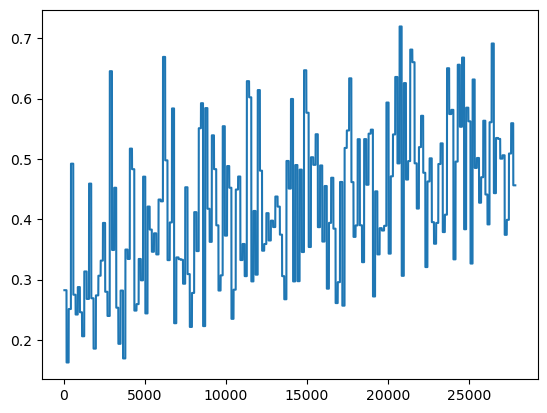

In [15]:
#ppg_time = np.linspace(0,len(ppg_data['r']) / 200,num=len(ppg_data['r']),endpoint=False)

#plt.plot(ac_signal_r/ac_signal_ir)
plt.plot(ac_values_r/ac_values_ir)

#Need to AVG data

In [32]:
#plt.plot((upper_env_ir-lower_env_ir)/(upper_env_r-lower_env_r))

%matplotlib qt
import matplotlib.pyplot as plt
import mplcursors
fig, ax = plt.subplots()  # <-- this is the key
ax.plot((upper_env_ir-lower_env_ir)/(upper_env_r-lower_env_r))

def format_coord(x, y):
    return f"x = {x:.10f}, y = {y:.10f}"

ax.format_coord = format_coord

mplcursors.cursor(hover=True)